# Week 3 — Baseline Models + Evaluation Framework

## 0. Imports + config

In [36]:
import sys, os, time, warnings
sys.path.append('..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.sparse as sp

from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
                                      train_test_split, learning_curve)
from sklearn.metrics         import classification_report
from imblearn.over_sampling  import SMOTE

from features import extract_features_batch, clean_texts_batch
from evaluate import (compute_metrics, cross_val_metrics, measure_inference_time,
                       plot_confusion_matrix, plot_results_table,
                       plot_cv_comparison, get_misclassified)

plt.rcParams.update({'figure.dpi':130,'font.family':'DejaVu Sans',
                     'axes.spines.top':False,'axes.spines.right':False})
LABEL_ORDER  = ['low','moderate','high']
PALETTE      = {'low':'#1D9E75','moderate':'#BA7517','high':'#D85A30'}
DOCS         = '../docs'
RANDOM_STATE = 42
os.makedirs(DOCS, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load data + build feature matrix

In [37]:
combined = '../data/processed/features_combined.csv'
kaggle   = '../data/processed/features_kaggle.csv'
data_path = combined if os.path.exists(combined) else kaggle
print(f'Using: {os.path.basename(data_path)}')

feat_df = pd.read_csv(data_path)
le      = joblib.load('../models/label_encoder.pkl')
vec     = joblib.load('../models/tfidf_vectorizer.pkl')

texts   = feat_df['text_clean'].fillna('').tolist()
y       = le.transform(feat_df['label'])
X_tfidf = vec.transform(texts)

ling_cols  = [c for c in feat_df.columns
              if c not in ['label','label_enc','text_clean','source']]
X_ling     = feat_df[ling_cols].fillna(0).values
X_combined = sp.hstack([X_tfidf, sp.csr_matrix(X_ling)])

print(f'TF-IDF     : {X_tfidf.shape}')
print(f'Combined   : {X_combined.shape}')
print(f'Labels     : {dict(zip(le.classes_, np.bincount(y)))}')
print(f'Classes    : {le.classes_}')

Using: features_kaggle.csv
TF-IDF     : (35631, 10000)
Combined   : (35631, 10024)
Labels     : {'high': 17651, 'low': 17980}
Classes    : ['high' 'low']


## 2. Train/test split + SMOTE



In [38]:
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X_combined, y, np.arange(len(y)),
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
texts_te = [texts[i] for i in idx_te]

print(f'Train: {X_tr.shape[0]}  |  Test: {X_te.shape[0]}')
print(f'Train dist : {np.bincount(y_tr)}')
print(f'Test  dist : {np.bincount(y_te)}')

sm = SMOTE(random_state=RANDOM_STATE)
X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)
print(f'After SMOTE train: {np.bincount(y_tr_sm)}')

Train: 28504  |  Test: 7127
Train dist : [14120 14384]
Test  dist : [3531 3596]
After SMOTE train: [14384 14384]


## 3. Logistic Regression

              precision    recall  f1-score   support

        high       0.95      0.91      0.93      3531
         low       0.91      0.95      0.93      3596

    accuracy                           0.93      7127
   macro avg       0.93      0.93      0.93      7127
weighted avg       0.93      0.93      0.93      7127

Inference   : 0.07 ms/sample  |  Train time: 42.50s


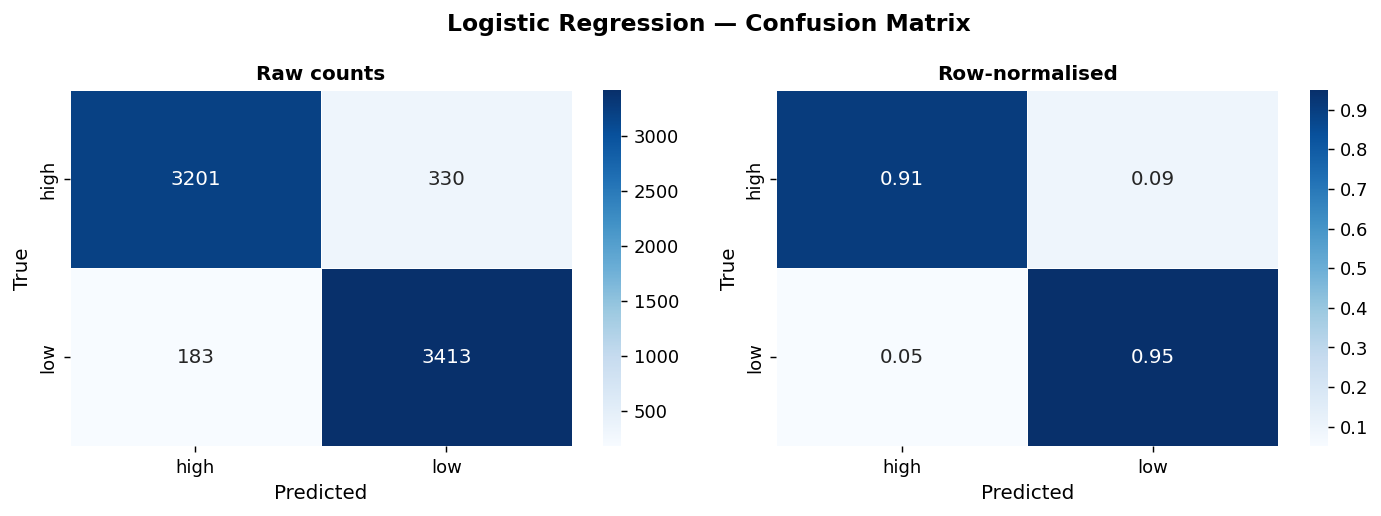

['../models/lr_model.pkl']

In [39]:
lr = LogisticRegression(class_weight='balanced', max_iter=5000,
                         random_state=RANDOM_STATE, C=1.0)
t0 = time.time()
lr.fit(X_tr_sm, y_tr_sm)
lr_train_time = time.time() - t0

y_pred_lr  = lr.predict(X_te)
lr_metrics = compute_metrics(y_te, y_pred_lr, le.classes_.tolist())
#lr_cv      = cross_val_metrics(lr, X_combined, y, cv=5)
lr_ms      = measure_inference_time(lr, X_te)

print(classification_report(y_te, y_pred_lr, target_names=le.classes_))
#print(f'CV F1-macro : {lr_cv["cv_f1_macro"]:.4f} ± {lr_cv["cv_f1_macro_std"]:.4f}')
#print(f'Overfit gap : {lr_cv["overfit_gap"]:.4f}')
print(f'Inference   : {lr_ms:.2f} ms/sample  |  Train time: {lr_train_time:.2f}s')

plot_confusion_matrix(y_te, y_pred_lr, le.classes_.tolist(),
                      'Logistic Regression — Confusion Matrix',
                      save_path=f'{DOCS}/plot_cm_lr.png')
joblib.dump(lr, '../models/lr_model.pkl', compress=3)


## 4.Linear SVM

              precision    recall  f1-score   support

        high       0.95      0.90      0.92      3531
         low       0.91      0.95      0.93      3596

    accuracy                           0.92      7127
   macro avg       0.93      0.92      0.92      7127
weighted avg       0.93      0.92      0.92      7127

CV F1-macro : 0.9221 ± 0.0019
Overfit gap : 0.0180
Inference   : 0.07 ms/sample  |  Train time: 3.76s


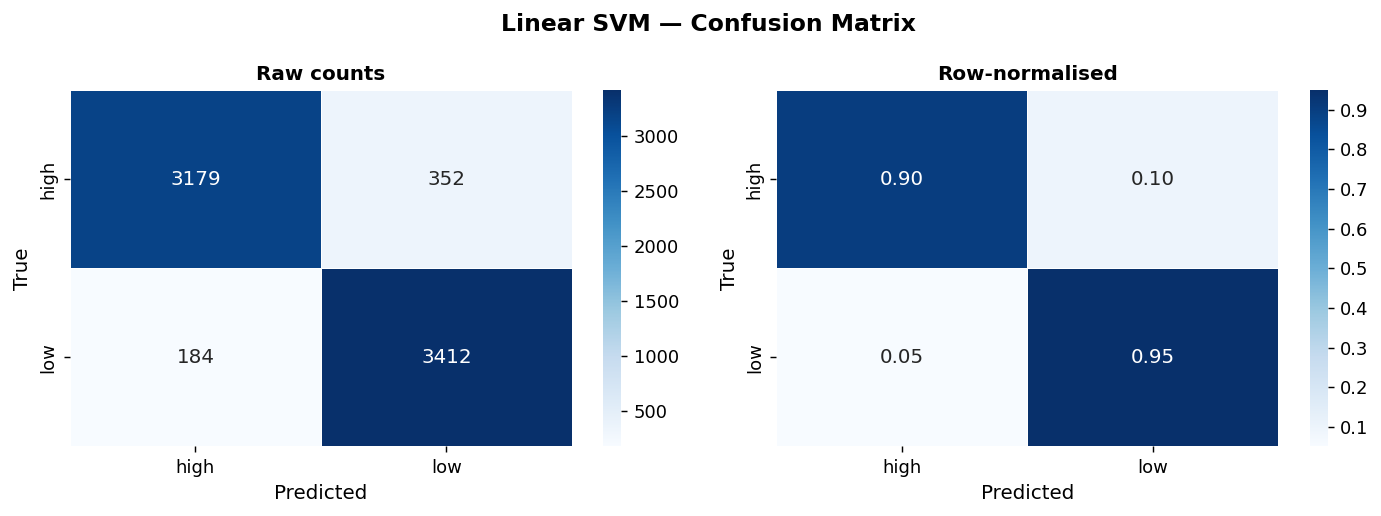

['../models/svm_model.pkl']

In [40]:
svm = LinearSVC(
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE,
    C=1.0,
    dual='auto'
)
t0 = time.time()
svm.fit(X_tr_sm, y_tr_sm)
svm_train_time = time.time() - t0

y_pred_svm  = svm.predict(X_te)
svm_metrics = compute_metrics(y_te, y_pred_svm, le.classes_.tolist())
svm_cv      = cross_val_metrics(svm, X_combined, y, cv=5)
svm_ms      = measure_inference_time(svm, X_te)

print(classification_report(y_te, y_pred_svm, target_names=le.classes_))
print(f'CV F1-macro : {svm_cv["cv_f1_macro"]:.4f} ± {svm_cv["cv_f1_macro_std"]:.4f}')
print(f'Overfit gap : {svm_cv["overfit_gap"]:.4f}')
print(f'Inference   : {svm_ms:.2f} ms/sample  |  Train time: {svm_train_time:.2f}s')

plot_confusion_matrix(y_te, y_pred_svm, le.classes_.tolist(),
                      'Linear SVM — Confusion Matrix',
                      save_path=f'{DOCS}/plot_cm_svm.png')
joblib.dump(svm, '../models/svm_model.pkl', compress=3)


## 5.Random Forest

              precision    recall  f1-score   support

        high       0.90      0.89      0.90      3531
         low       0.90      0.90      0.90      3596

    accuracy                           0.90      7127
   macro avg       0.90      0.90      0.90      7127
weighted avg       0.90      0.90      0.90      7127

CV F1-macro : 0.8992 ± 0.0057
Overfit gap : 0.1007
Inference   : 12.11 ms/sample  |  Train time: 8.45s


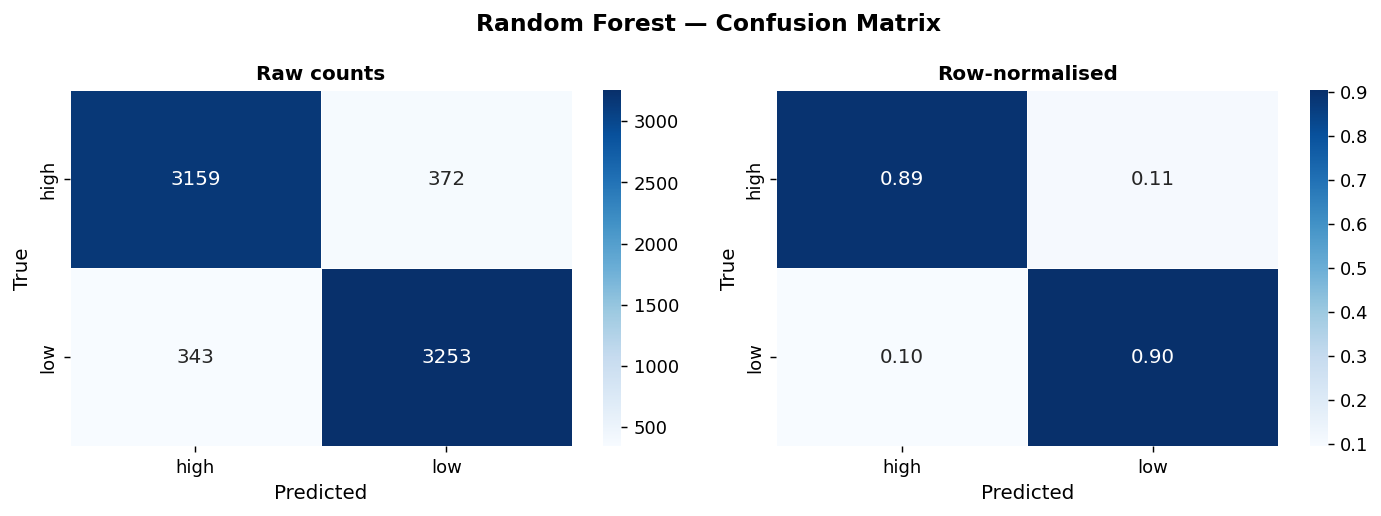

['../models/rf_model.pkl']

In [41]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                              random_state=RANDOM_STATE, n_jobs=-1)
t0 = time.time()
rf.fit(X_tr_sm, y_tr_sm)
rf_train_time = time.time() - t0

y_pred_rf  = rf.predict(X_te)
rf_metrics = compute_metrics(y_te, y_pred_rf, le.classes_.tolist())
rf_cv      = cross_val_metrics(rf, X_combined, y, cv=5)
rf_ms      = measure_inference_time(rf, X_te)

print(classification_report(y_te, y_pred_rf, target_names=le.classes_))
print(f'CV F1-macro : {rf_cv["cv_f1_macro"]:.4f} ± {rf_cv["cv_f1_macro_std"]:.4f}')
print(f'Overfit gap : {rf_cv["overfit_gap"]:.4f}')
print(f'Inference   : {rf_ms:.2f} ms/sample  |  Train time: {rf_train_time:.2f}s')

plot_confusion_matrix(y_te, y_pred_rf, le.classes_.tolist(),
                      'Random Forest — Confusion Matrix',
                      save_path=f'{DOCS}/plot_cm_rf.png')
joblib.dump(rf, '../models/rf_model.pkl', compress=3)


## 6. Hyperparameter tuning (GridSearchCV)

In [42]:
TUNE_MODEL = 'lr'

param_grids = {
    'lr' : {'C':[0.01,0.1,1.0,5.0,10.0],'solver': ['liblinear']},
    'svm': {'C':[0.01,0.1,0.5,1.0,5.0,10.0]},
}
base_models = {
    'lr' : LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'svm': LinearSVC(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE),
}

print(f'GridSearchCV: {TUNE_MODEL.upper()} (5-fold, f1_macro scoring)...')
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(base_models[TUNE_MODEL], param_grids[TUNE_MODEL],
                  cv=cv_inner, scoring='f1_macro', n_jobs=-1, verbose=1)
t0 = time.time()
gs.fit(X_tr_sm, y_tr_sm)
print(f'\nTime        : {time.time()-t0:.1f}s')
print(f'Best params : {gs.best_params_}')
print(f'Best CV F1  : {gs.best_score_:.4f}')

best_model   = gs.best_estimator_
y_pred_best  = best_model.predict(X_te)
best_metrics = compute_metrics(y_te, y_pred_best, le.classes_.tolist())
print(f'Test F1-macro (tuned): {best_metrics["f1_macro"]:.4f}')
joblib.dump(best_model, f'../models/{TUNE_MODEL}_tuned.pkl', compress=3)


GridSearchCV: LR (5-fold, f1_macro scoring)...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Time        : 46.7s
Best params : {'C': 5.0, 'solver': 'liblinear'}
Best CV F1  : 0.9179
Test F1-macro (tuned): 0.9211


['../models/lr_tuned.pkl']

## 7. Cross-validation comparison

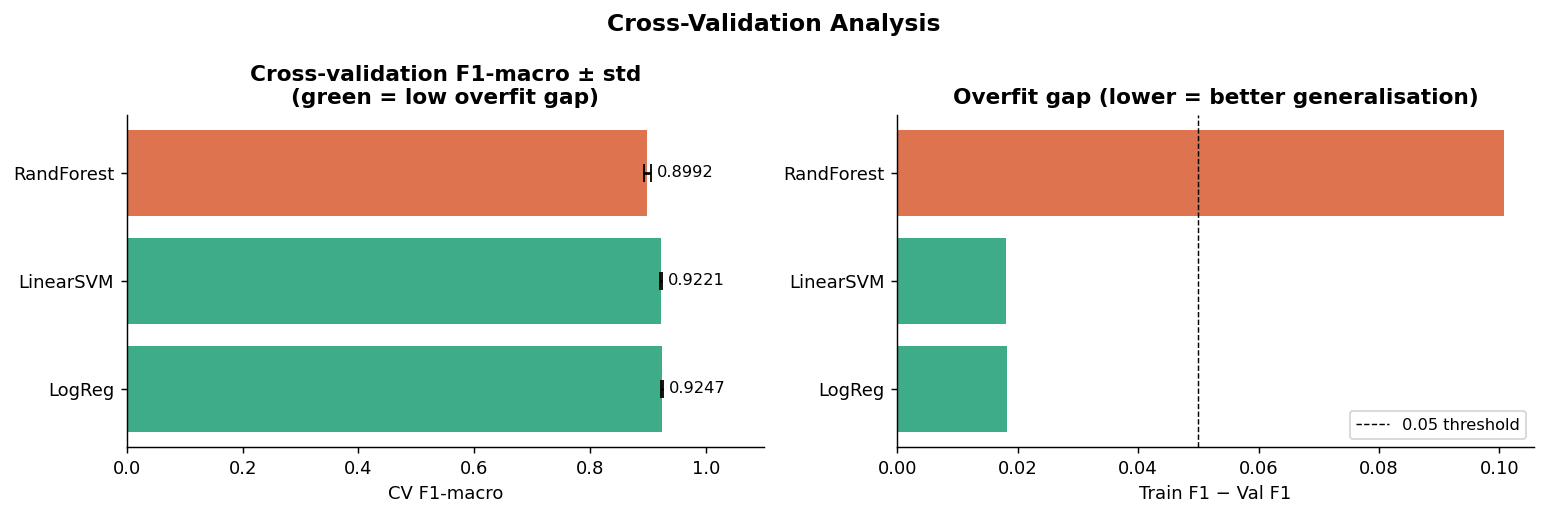

In [43]:
cv_results = {
    'LogReg'    : lr_cv,
    'LinearSVM' : svm_cv,
    'RandForest': rf_cv,
}
plot_cv_comparison(cv_results, save_path=f'{DOCS}/plot_cv_comparison.png')


## 8. Learning curve

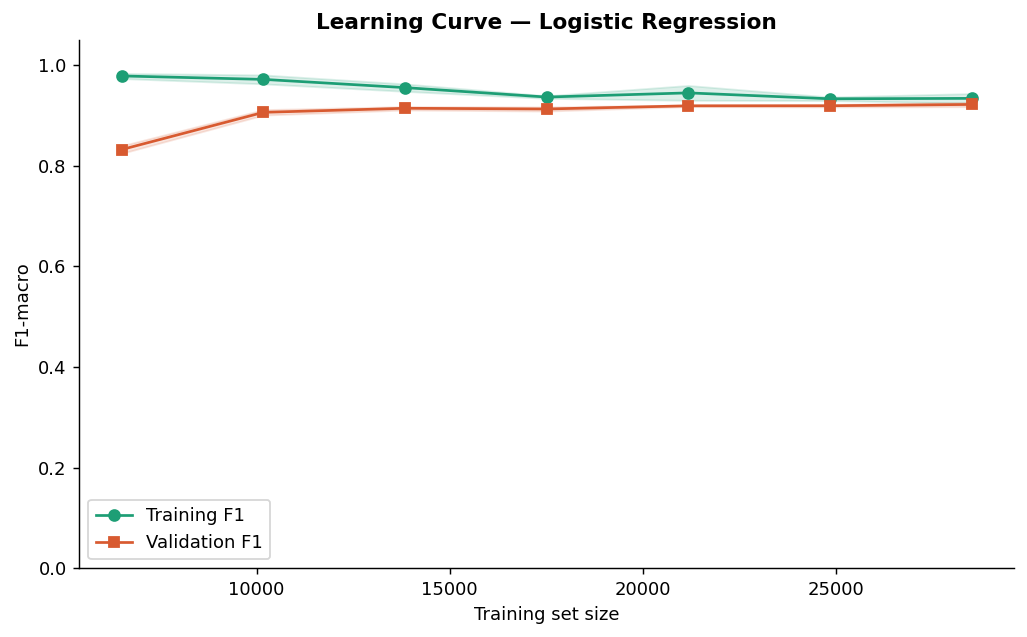

Overfit gap at full data: 0.0121


In [44]:
lc_model = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=5000,
    random_state=RANDOM_STATE,
    C=5.0
)
train_sizes, train_scores, val_scores = learning_curve(
    lc_model, X_combined, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)
tr_mean, tr_std = train_scores.mean(1), train_scores.std(1)
va_mean, va_std = val_scores.mean(1),   val_scores.std(1)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(train_sizes, tr_mean, 'o-', color='#1D9E75', label='Training F1')
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='#1D9E75')
ax.plot(train_sizes, va_mean, 's-', color='#D85A30', label='Validation F1')
ax.fill_between(train_sizes, va_mean-va_std, va_mean+va_std, alpha=0.15, color='#D85A30')
ax.set_xlabel('Training set size'); ax.set_ylabel('F1-macro')
ax.set_title('Learning Curve — Logistic Regression', fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f'{DOCS}/plot_learning_curve.png', bbox_inches='tight')
plt.show()

gap_at_max = tr_mean[-1] - va_mean[-1]
print(f'Overfit gap at full data: {gap_at_max:.4f}')


## 9. Error analysis

Error type breakdown:
error_type
high → low    17
low → high    13
Name: count, dtype: int64

Errors: 30 / 7127 (0.4%)
error_type
high → low    17
low → high    13
Name: count, dtype: int64


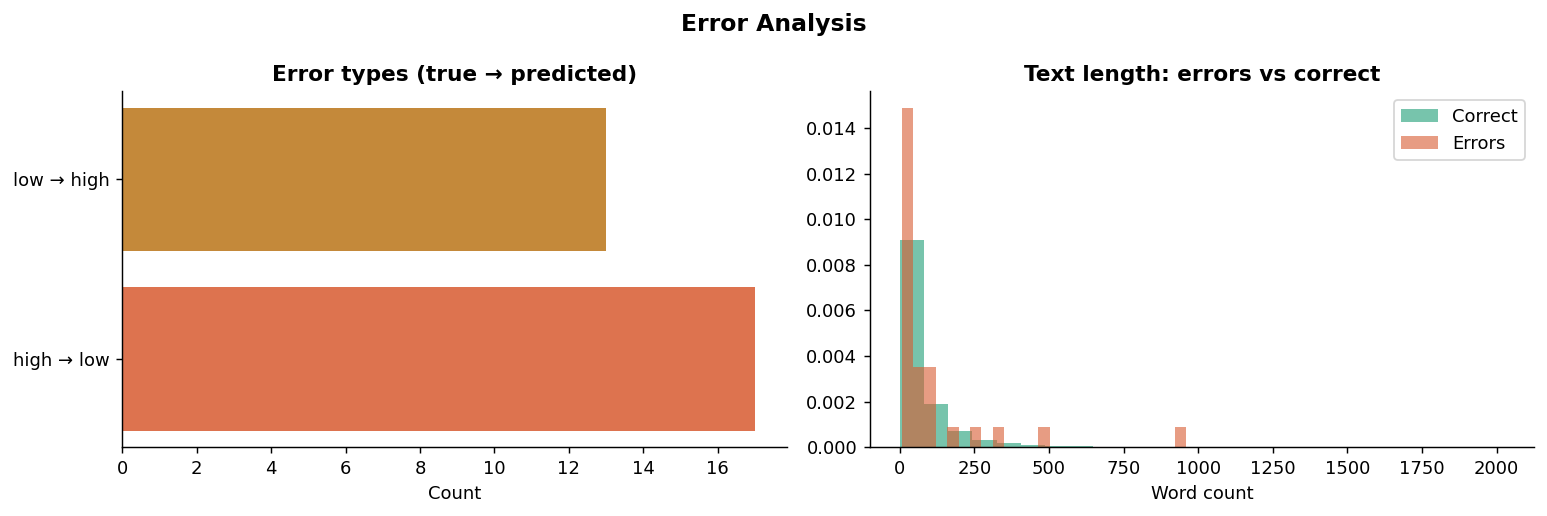

In [45]:
errors = get_misclassified(texts_te, y_te, y_pred_lr, le.classes_.tolist(), n=30)
print(f'Errors: {len(errors)} / {len(y_te)} ({len(errors)/len(y_te)*100:.1f}%)')
print(errors['error_type'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
err_counts = errors['error_type'].value_counts()
colors = ['#D85A30','#BA7517','#7F77DD','#1D9E75'][:len(err_counts)]
axes[0].barh(err_counts.index, err_counts.values, color=colors, alpha=0.85)
axes[0].set_title('Error types (true → predicted)', fontweight='bold')
axes[0].set_xlabel('Count')

all_lens = [len(t.split()) for t in texts_te]
err_lens = [len(texts_te[i].split()) for i in range(min(len(errors),len(texts_te)))]
ok_lens  = [l for i,l in enumerate(all_lens) if i >= len(errors)]
axes[1].hist(ok_lens,  bins=25, alpha=0.6, label='Correct', color='#1D9E75', density=True)
axes[1].hist(err_lens, bins=25, alpha=0.6, label='Errors',  color='#D85A30', density=True)
axes[1].set_xlabel('Word count')
axes[1].set_title('Text length: errors vs correct', fontweight='bold')
axes[1].legend()
plt.suptitle('Error Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/plot_error_analysis.png', bbox_inches='tight')
plt.show()



## 10. Imbalance strategy comparison

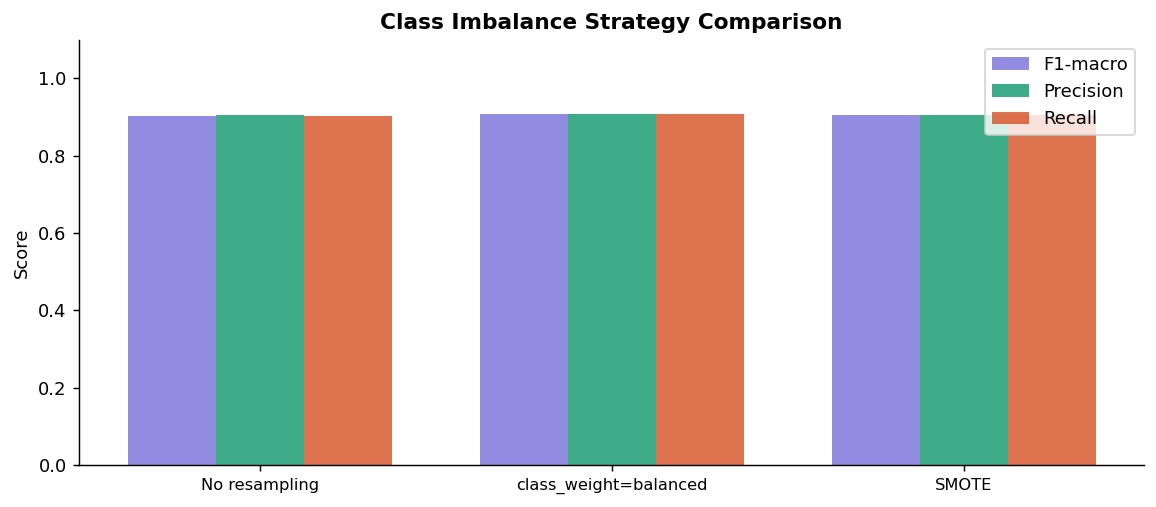

In [46]:
strategies = {
    'No resampling': (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0),
        X_tr, y_tr),
    'class_weight=balanced': (
        LogisticRegression(class_weight='balanced', max_iter=1000,
                           random_state=RANDOM_STATE, C=1.0),
        X_tr, y_tr),
    'SMOTE': (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0),
        X_tr_sm, y_tr_sm),
}
strat_results = []
for name, (m, Xtr, ytr) in strategies.items():
    m.fit(Xtr, ytr)
    pred = m.predict(X_te)
    met  = compute_metrics(y_te, pred, le.classes_.tolist())
    strat_results.append({'strategy':name, **met})
    hi_f1 = met['per_class_f1'].get('high', met['per_class_f1'].get(le.classes_[-1], 0))
    
strat_df = pd.DataFrame(strat_results)
fig, ax = plt.subplots(figsize=(9,4))
x = np.arange(len(strat_df)); w = 0.25
ax.bar(x-w, strat_df['f1_macro'],       w, label='F1-macro',  color='#7F77DD', alpha=0.85)
ax.bar(x,   strat_df['precision_macro'],w, label='Precision', color='#1D9E75', alpha=0.85)
ax.bar(x+w, strat_df['recall_macro'],   w, label='Recall',    color='#D85A30', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(strat_df['strategy'], fontsize=9)
ax.set_ylabel('Score'); ax.set_ylim(0,1.1)
ax.set_title('Class Imbalance Strategy Comparison', fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig(f'{DOCS}/plot_imbalance_strategies.png', bbox_inches='tight')
plt.show()

## 11. Build results comparison table

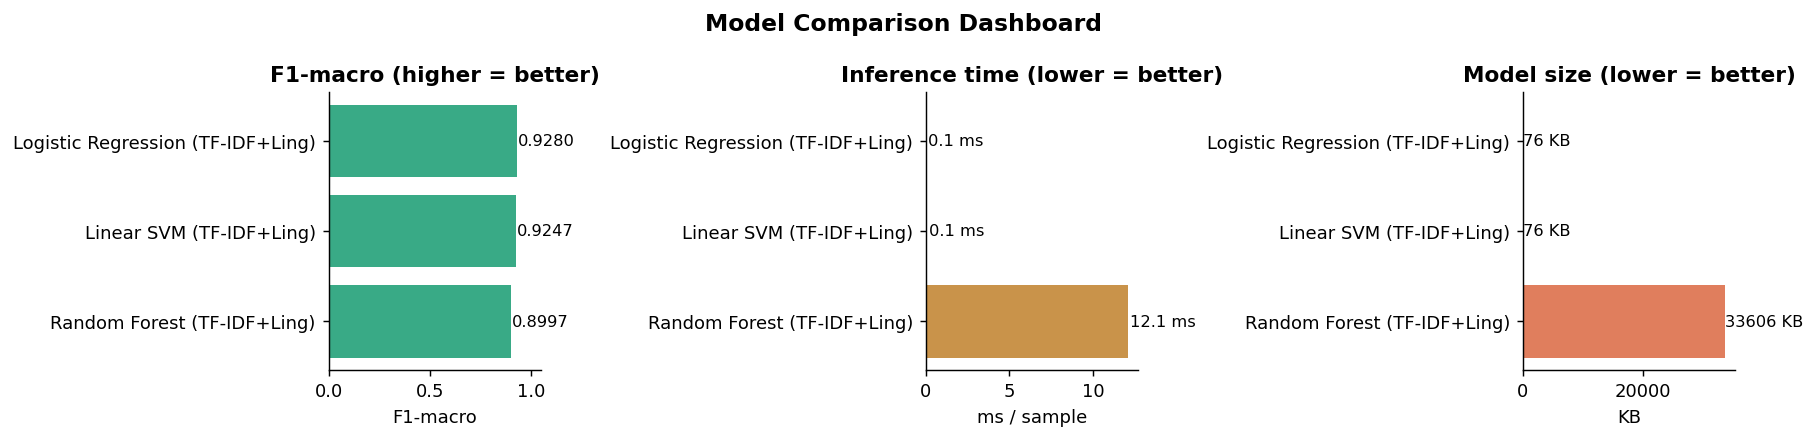

In [47]:
def model_kb(model, tag):
    p = f'../models/_sz_{tag}.pkl'
    joblib.dump(model, p, compress=3)
    kb = os.path.getsize(p)/1024
    os.remove(p)
    return round(kb,1)

results_rows = [
    dict(model='Logistic Regression (TF-IDF+Ling)',
         f1_macro=lr_metrics['f1_macro'], f1_weighted=lr_metrics['f1_weighted'],
         precision_macro=lr_metrics['precision_macro'], recall_macro=lr_metrics['recall_macro'],
         cv_f1_macro=lr_cv['cv_f1_macro'], cv_f1_std=lr_cv['cv_f1_macro_std'],
         overfit_gap=lr_cv['overfit_gap'], inference_ms=lr_ms, model_size_kb=model_kb(lr,'lr')),
    dict(model='Linear SVM (TF-IDF+Ling)',
         f1_macro=svm_metrics['f1_macro'], f1_weighted=svm_metrics['f1_weighted'],
         precision_macro=svm_metrics['precision_macro'], recall_macro=svm_metrics['recall_macro'],
         cv_f1_macro=svm_cv['cv_f1_macro'], cv_f1_std=svm_cv['cv_f1_macro_std'],
         overfit_gap=svm_cv['overfit_gap'], inference_ms=svm_ms, model_size_kb=model_kb(svm,'svm')),
    dict(model='Random Forest (TF-IDF+Ling)',
         f1_macro=rf_metrics['f1_macro'], f1_weighted=rf_metrics['f1_weighted'],
         precision_macro=rf_metrics['precision_macro'], recall_macro=rf_metrics['recall_macro'],
         cv_f1_macro=rf_cv['cv_f1_macro'], cv_f1_std=rf_cv['cv_f1_macro_std'],
         overfit_gap=rf_cv['overfit_gap'], inference_ms=rf_ms, model_size_kb=model_kb(rf,'rf')),
    dict(model='DistilBERT fine-tuned 🔜',
         f1_macro=None, f1_weighted=None, precision_macro=None, recall_macro=None,
         cv_f1_macro=None, cv_f1_std=None, overfit_gap=None,
         inference_ms=None, model_size_kb=255000),
]
results_df = pd.DataFrame(results_rows)
results_df.to_csv('../data/processed/results_table.csv', index=False)

plot_results_table(
    results_df[results_df['f1_macro'].notna()],
    save_path=f'{DOCS}/plot_results_table.png'
)
